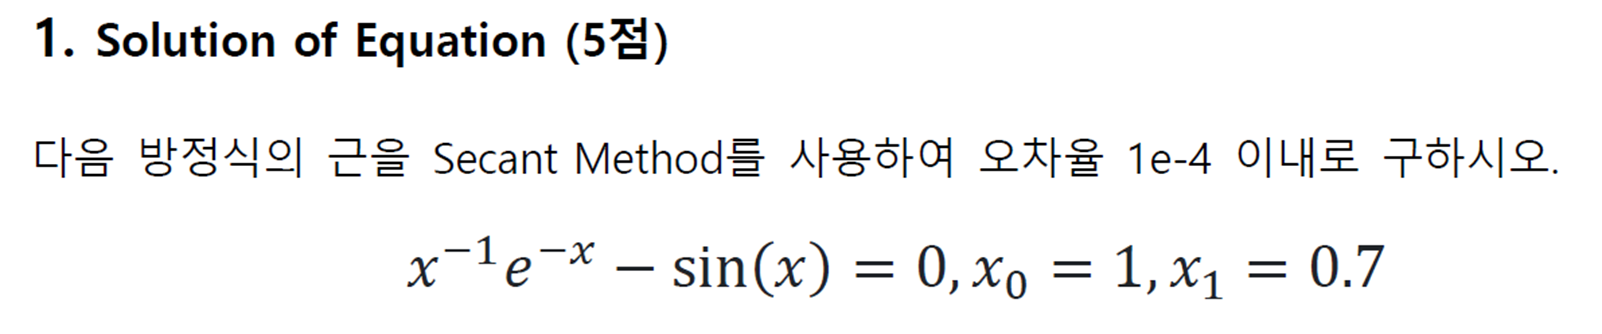

# 문제 1 답: 0.727097

In [2]:
import numpy as np

def func(x):
    return 1/x*np.exp(-x)-np.sin(x)

N = 10; x0 = 1; x1 = 0.7; tol = 1e-4; xn = x0; xnn=x1

for i in range(N):
  func_p = (func(xnn)-func(xn))/(xnn-xn)
  xnnn = xn - func(xn)/func_p
  error = (xnnn - xnn)/xnnn
  print(f'n:{i}, xn:{xn:.6f}, xn+1:{xnn:.6f}, , xn+2:{xnnn:.6f}, error:{error:.6e}')
  xn = xnn
  xnn = xnnn
  if abs(error) < tol:
      break

print(f'Solution of 1/x*exp(-x)-sin(x)=0 is {xn:.6f}')

n:0, xn:1.000000, xn+1:0.700000, , xn+2:0.736299, error:4.929864e-02
n:1, xn:0.700000, xn+1:0.736299, , xn+2:0.727404, error:-1.222706e-02
n:2, xn:0.736299, xn+1:0.727404, , xn+2:0.727097, error:-4.227023e-04
n:3, xn:0.727404, xn+1:0.727097, , xn+2:0.727101, error:4.690501e-06
Solution of 1/x*exp(-x)-sin(x)=0 is 0.727097


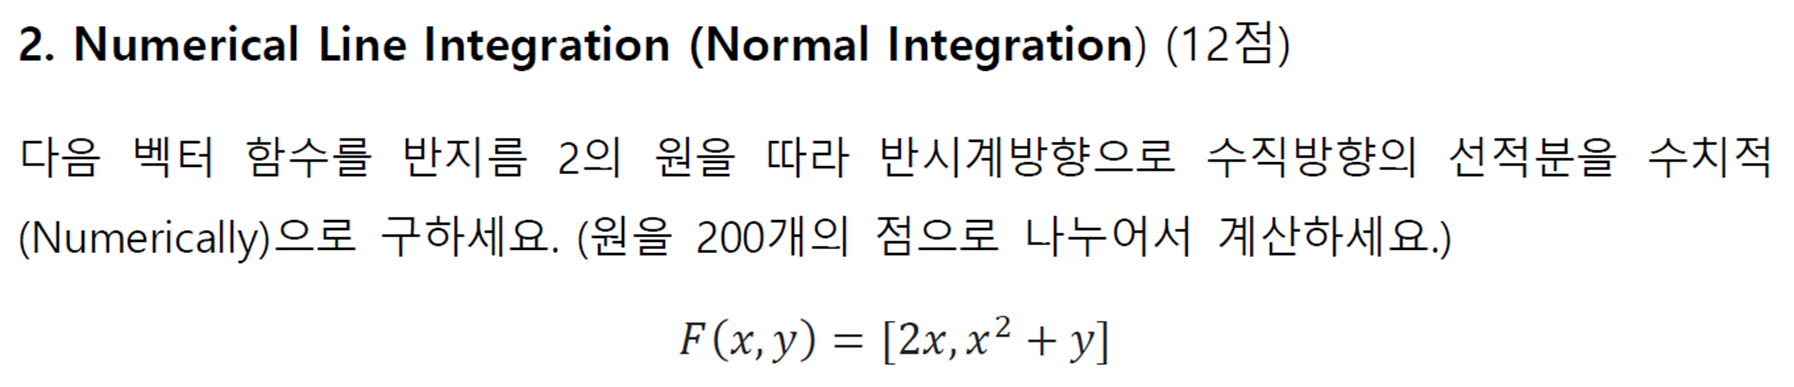

# 문제 2 정답: 37.6991

In [7]:
import numpy as np
import scipy.integrate as integrate

# Define the temperature function T(x, y) and its gradient
def func(x, y):
    return 2*x, x**2 + y

# Parametrize the circle
def circle_param(theta, radius=2):
    return radius * np.cos(theta), radius * np.sin(theta)

# Gradient of T along the circle
def grad_T_circle(theta):
    x, y = circle_param(theta)
    U, V = func(x, y)
    # dx/dtheta and dy/dtheta
    dx_dtheta = -2 * np.sin(theta)
    dy_dtheta = 2 * np.cos(theta)
    # Dot product of gradient and differential element of the path
    return U * dy_dtheta - V * dx_dtheta

theta_array = np.linspace(0, 2*np.pi,200)
d_theta = theta_array[1] - theta_array[0]

integral = 0
for th in theta_array: # Numerical integration around the circle

    if th == 0 or th == 2*np.pi:
        integral += grad_T_circle(th)*d_theta/2
    else:
        integral += grad_T_circle(th)*d_theta
integral

np.float64(37.69911184307751)

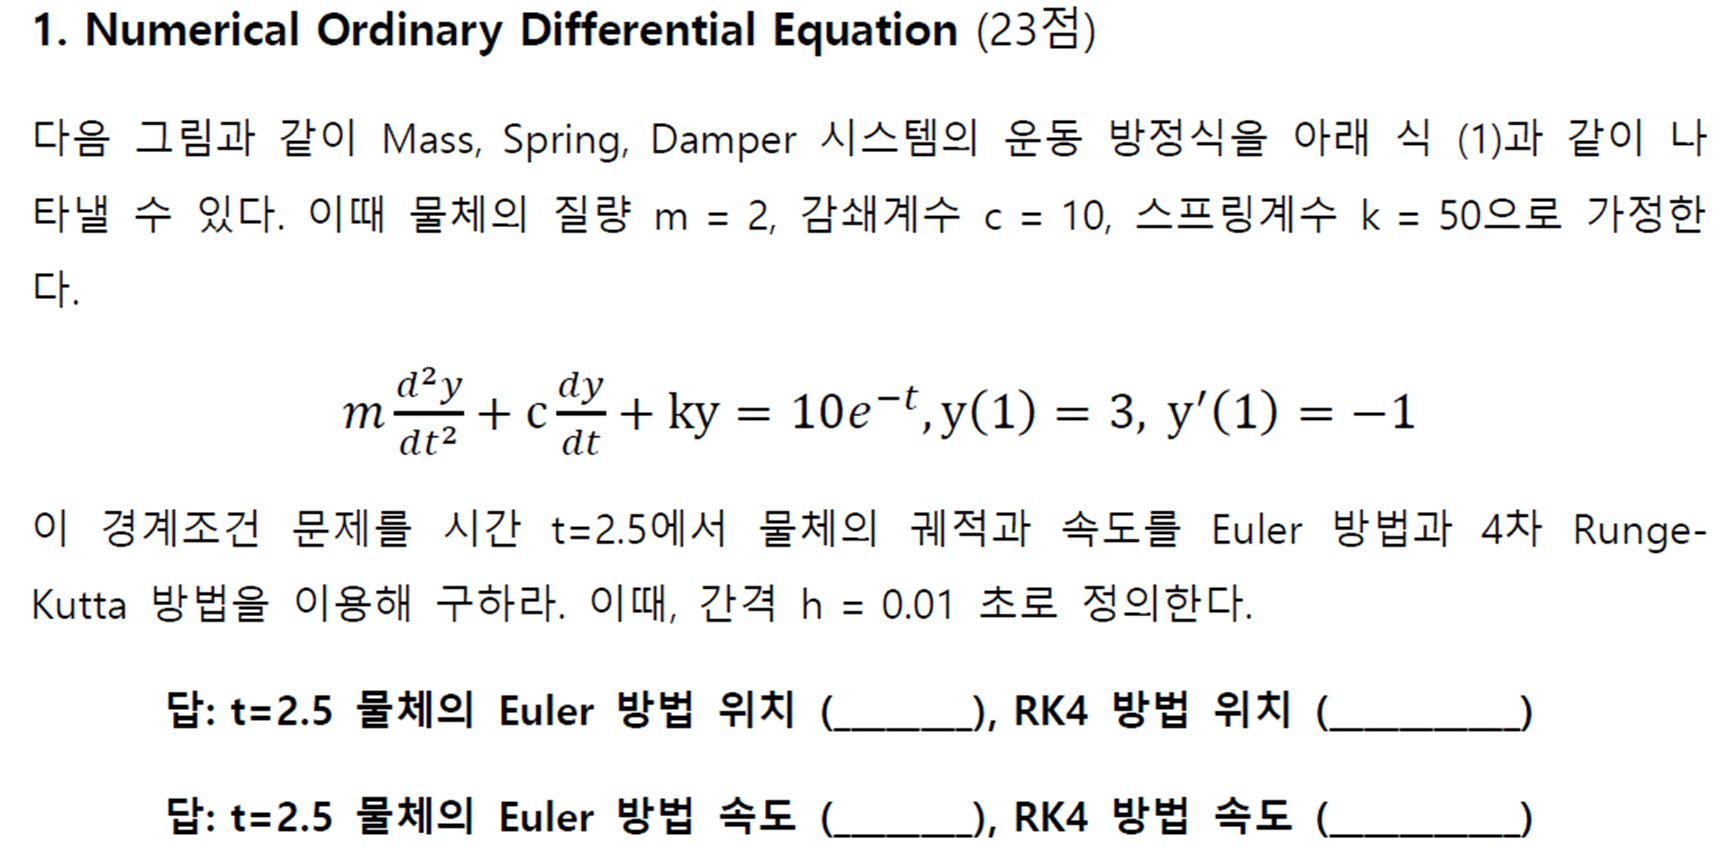

# 문제 3 정답: RK4 해 = 0.09378, Euler 해: 0.10397

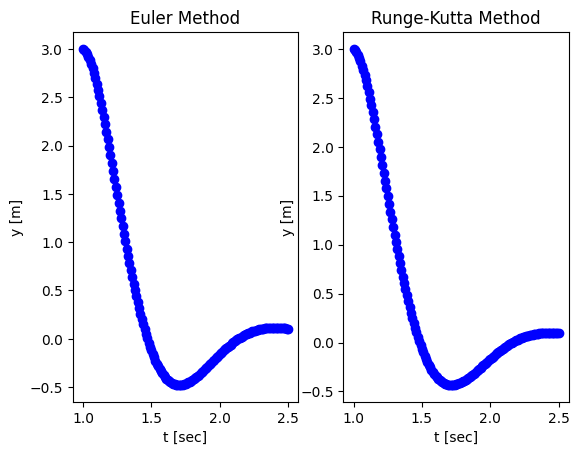

In [13]:
def func_y1(t, y1, y2) :
    return y2
m, c, k = 2, 10, 50
def func_y2(t, y1, y2) :
    return (-c*y2 - k*y1 + 10*np.exp(-t))/m

ti = 1
y1_i = 3
y2_i = -1

ts = []
ys_E = []

h = 0.01
N = 150
for i in range(N+1) :
    y1_i1 = y1_i + h*func_y1(ti, y1_i, y2_i)
    y2_i1 = y2_i + h*func_y2(ti, y1_i, y2_i)

    ts.append(ti)
    ys_E.append(y1_i)

    ti += h
    y1_i = y1_i1
    y2_i = y2_i1

ti = 1
y1_i = 3
y2_i = -1

ts = []
ys_R = []

for i in range(N+1) :
    a1 = func_y1(ti, y1_i, y2_i)
    a2 = func_y2(ti, y1_i, y2_i)

    b1 = func_y1(ti + h/2, y1_i + h/2 * a1, y2_i + h/2 * a2)
    b2 = func_y2(ti + h/2, y1_i + h/2 * a1, y2_i + h/2 * a2)

    c1 = func_y1(ti + h/2, y1_i + h/2 * b1, y2_i + h/2 * b2)
    c2 = func_y2(ti + h/2, y1_i + h/2 * b1, y2_i + h/2 * b2)

    d1 = func_y1(ti + h, y1_i + h * c1, y2_i + h * c2)
    d2 = func_y2(ti + h, y1_i + h * c1, y2_i + h * c2)

    y1_i1 = y1_i + h/6*(a1 + 2*b1 + 2*c1 + d1)
    y2_i1 = y2_i + h/6*(a2 + 2*b2 + 2*c2 + d2)

    ts.append(ti)
    ys_R.append(y1_i)

    ti += h
    y1_i = y1_i1
    y2_i = y2_i1

import matplotlib.pyplot as plt

fig = plt.figure()
ax1 = fig.add_subplot(121)
ax1.set_xlabel('t [sec]')
ax1.set_ylabel('y [m]')
ax1.plot(ts, ys_E, 'o', color='b')
ax1.title.set_text('Euler Method')

ax2 = fig.add_subplot(122)
ax2.plot(ts, ys_R, 'o', color='b')
ax2.set_xlabel('t [sec]')
ax2.set_ylabel('y [m]')
ax2.title.set_text('Runge-Kutta Method')

In [20]:
ys_E[-1], ys_R[-1]

(np.float64(0.10397177365765756), np.float64(0.09378215236083898))